In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

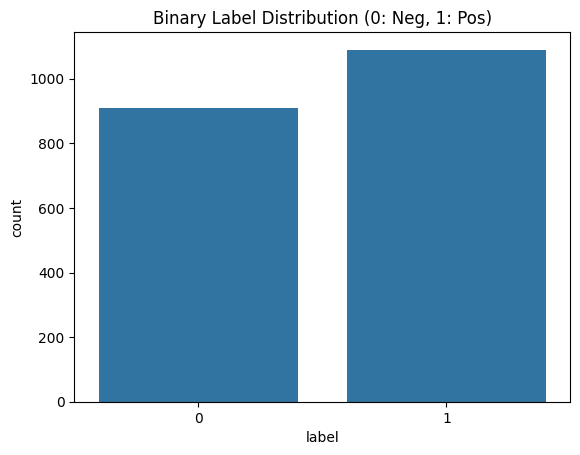

패딩 후 데이터 형태: (2000, 100)
라벨 데이터 형태: (2000,)

--- 모델 학습 시작 ---
Epoch 1/15


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5625 - loss: 0.6605 - val_accuracy: 0.8425 - val_loss: 0.5585
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9513 - loss: 0.2798 - val_accuracy: 0.9925 - val_loss: 0.0738
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9881 - loss: 0.0650 - val_accuracy: 0.9925 - val_loss: 0.0515
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9881 - loss: 0.0467 - val_accuracy: 0.9925 - val_loss: 0.0515
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9919 - loss: 0.0347 - val_accuracy: 0.9925 - val_loss: 0.0500
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9956 - loss: 0.0242 - val_accuracy: 0.9900 - val_loss: 0.0545
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9962 - loss: 0.0194 - val_accuracy: 0.9900 - val_loss: 0.0582
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9975 - loss: 0.0154 - val_accuracy: 0.9875 - val_loss: 0.

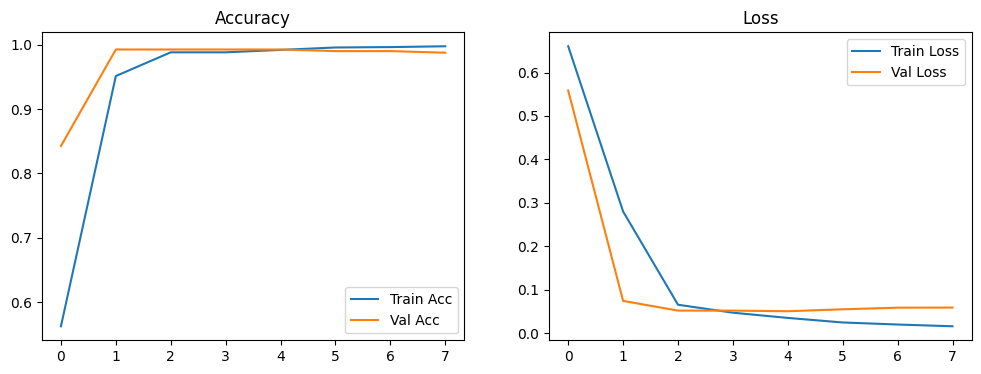

In [2]:
# 1. 데이터 로드
df = pd.read_csv('./data/naver_style_reviews_2000_diverse.csv')

# 2. 라벨 전처리 (가장 중요!)
# rating이 4, 5면 긍정(1), 1, 2면 부정(0)으로 변환합니다. (3점 중립은 보통 제거하여 성능을 높입니다)
# df = df[df['rating'] != 3] 
df['label'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)

# 3. 텍스트 정제 함수
def clean_text(text):
    if not isinstance(text, str): return ""
    # 특수문자 및 자음/모음 제거 (re 활용)
    text = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', text) # 한글, 영문, 숫자만 남김
    text = re.sub(r'[ㄱ-ㅎㅏ-ㅣ]+', '', text) # ㅋㅋ, ㅠㅠ 제거
    text = re.sub(r'\s+', ' ', text).strip() # 중복 공백 제거
    return text

df['cleaned_review'] = df['review_text'].fillna('').apply(clean_text)

# 4. EDA (분포 확인)
sns.countplot(x='label', data=df)
plt.title('Binary Label Distribution (0: Neg, 1: Pos)')
plt.show()

# 5. 토큰화 및 패딩
vocab_size = 5000
max_len = 100

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df['cleaned_review'])
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])

# 단어 사전 크기 재설정 (실제 단어 수와 vocab_size 중 작은 값 사용)
actual_vocab_size = min(len(tokenizer.word_index) + 1, vocab_size)

X_padded = pad_sequences(sequences, maxlen=max_len, padding='pre')
y = df['label'].values # 평점 대신 변환한 label 사용

print(f"패딩 후 데이터 형태: {X_padded.shape}")
print(f"라벨 데이터 형태: {y.shape}")

# 6. CNN + LSTM 모델 설계
model = Sequential([
    # 실제 단어 사전 크기를 반영
    Embedding(actual_vocab_size, 128, input_length=max_len),
    Dropout(0.3),
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(pool_size=4),
    LSTM(64),
    Dense(1, activation='sigmoid') # 0~1 사이의 확률값 출력
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 7. 모델 학습
print("\n--- 모델 학습 시작 ---")
history = model.fit(
    X_padded, y, 
    epochs=15, 
    batch_size=64, 
    validation_split=0.2, 
    callbacks=[early_stop]
)

# 8. 결과 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [4]:
def predict_sentiment_v2(new_sentence, model, tokenizer):
    # 위에서 정의한 함수 이름은 clean_text이므로 똑같이 맞춰줍니다.
    cleaned = clean_text(new_sentence) 
    encoded = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(encoded, maxlen=100, padding='pre')
    
    # predict 결과물 추출 방식은 유지
    prediction = model.predict(padded)
    score = float(prediction[0][0])
    
    if score > 0.5:
        print(f"'{new_sentence}' -> 긍정 리뷰 ({score*100:.2f}% 확률)")
    else:
        print(f"'{new_sentence}' -> 부정 리뷰 ({(1-score)*100:.2f}% 확률)")

print("\n--- 실제 데이터 예측 테스트 (재학습 후) ---")
test_reviews = [
    "배송이 정말 빠르고 제품도 튼튼해서 너무 만족해요!",
    "퀄리티가 너무 낮고 금방 고장났어요. 다시는 안 삽니다.",
    "그냥저냥 쓸만해요. ㅋㅋㅋ",
    "포장이 너무 허술해서 제품이 다 찌그러져서 왔네요."
]

for review in test_reviews:
    predict_sentiment_v2(review, model, tokenizer)


--- 실제 데이터 예측 테스트 (재학습 후) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
'배송이 정말 빠르고 제품도 튼튼해서 너무 만족해요!' -> 부정 리뷰 (80.20% 확률)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
'퀄리티가 너무 낮고 금방 고장났어요. 다시는 안 삽니다.' -> 부정 리뷰 (98.15% 확률)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
'그냥저냥 쓸만해요. ㅋㅋㅋ' -> 부정 리뷰 (81.02% 확률)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
'포장이 너무 허술해서 제품이 다 찌그러져서 왔네요.' -> 부정 리뷰 (66.21% 확률)
